In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import hdbscan
import umap
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import zscore

Dataset: <br>
League - All <br>
Year(s) - 2021-25 <br>

In [ ]:
# --- 1. DATA PREPARATION ---
df = pd.read_csv('../data/v2/Final_DataSet_All_Fixed.csv') # primary change is to confirm data switches

# Determine Final Outcomes
filtered_ft = df.loc[df['Time'] == 'FT'].copy()
conditions = [
    (filtered_ft['Home_Score'] > filtered_ft['Away_Score']),
    (filtered_ft['Away_Score'] > filtered_ft['Home_Score']),
    (filtered_ft['Home_Score'] == filtered_ft['Away_Score'])
]
choices = ['Home_Win', 'Away_Win', 'Draw']
filtered_ft['Match_Outcomes'] = np.select(conditions, choices, default='Unknown')
outcome_map = dict(zip(filtered_ft['Game_ID'], filtered_ft['Match_Outcomes']))
df['Match_Outcomes'] = df['Game_ID'].map(outcome_map)

# Preprocessing
df_mod = df[(df['Time'] != 'FT') & (df['Matchweek'] != 'Cup')].copy()
df_mod['Time'] = df_mod['Time'].apply(eval)

# --- NEW: 5-MINUTE TIME BINNING ---
# Moving from 15m to 5m bins to capture higher resolution tactical shifts.
df_mod['Time_Bin'] = (df_mod['Time'] // 5).astype(int)

df_mod['Score_Diff'] = df_mod['Home_Score'] - df_mod['Away_Score']
df_mod['Home_Score_Log'] = np.log1p(df_mod['Home_Score'])
df_mod['Away_Score_Log'] = np.log1p(df_mod['Away_Score'])

features = ['Time_Bin', 'Score_Diff', 'Home_Score_Log', 'Away_Score_Log', 
            'Home_Red_Count', 'Away_Red_Count', 'Home_Off_Sub_Count', 'Away_Off_Sub_Count']
X = df_mod[features].fillna(0)
y_true = df_mod['Match_Outcomes']

# Scaling with Jitter
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X + np.random.normal(0, 1e-5, X.shape))

--- Stage 1: Running Baseline (5-Minute Resolution) ---


C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


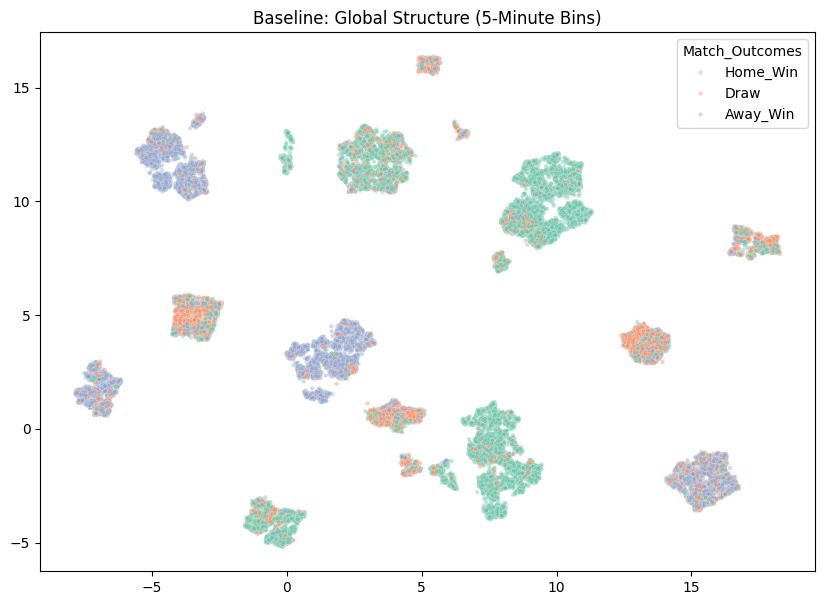


REASONING FOR NEXT STEP:
By reducing the time bins to 5 minutes, we've increased the model's 'vision'.
We can now see smaller islands that likely represent specific windows like 'Final 5 Mins'.
We will now move to 3D Supervised UMAP to ensure these high-resolution time blocks
don't cause overlapping outcome clusters.


In [3]:
# STAGE 1: BASELINE (High-Resolution Global Structure)
# =================================================================
print("--- Stage 1: Running Baseline (5-Minute Resolution) ---")
reducer_base = umap.UMAP(n_neighbors=30, min_dist=0.1, metric='canberra', init='random', random_state=42)
X_umap_base = reducer_base.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_umap_base[:, 0], y=X_umap_base[:, 1], hue=y_true, s=10, alpha=0.4, palette='Set2')
plt.title("Baseline: Global Structure (5-Minute Bins)")
plt.show()

print("\nREASONING FOR NEXT STEP:")
print("By reducing the time bins to 5 minutes, we've increased the model's 'vision'.")
print("We can now see smaller islands that likely represent specific windows like 'Final 5 Mins'.")
print("We will now move to 3D Supervised UMAP to ensure these high-resolution time blocks")
print("don't cause overlapping outcome clusters.")


--- Stage 2: Supervised 2D & 3D UMAP + HDBSCAN ---


C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


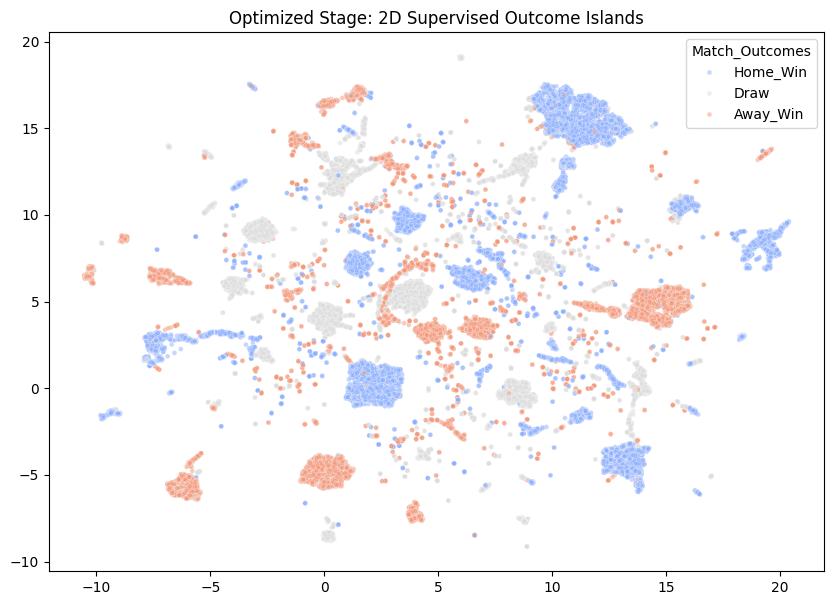

C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


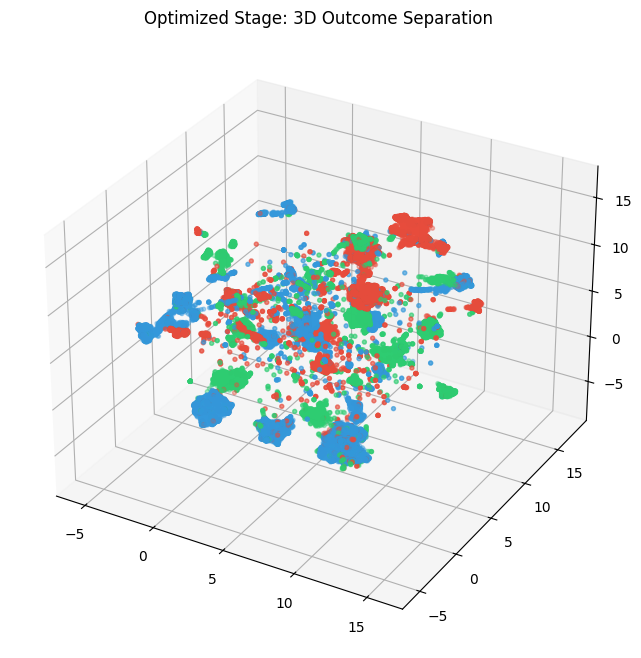


REASONING FOR NEXT STEP:
We have added a 2D optimized view alongside the 3D projection. While 3D provides
depth to separate Draws from Wins, the 2D view is often clearer for identifying
how 'Home Win' clusters flow into each other as time increases. We now move to
Stage 3 to analyze the statistical signatures of these separated islands.


In [4]:
# STAGE 2: OPTIMIZED (2D & 3D Supervised Separation)
# =================================================================
print("\n--- Stage 2: Supervised 2D & 3D UMAP + HDBSCAN ---")

y_encoded, _ = pd.factorize(y_true)

# --- 2D SUPERVISED PROJECTION ---
reducer_2d = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    target_weight=0.9,
    metric='canberra',
    init='random',
    random_state=42
)
X_umap_2d = reducer_2d.fit_transform(X_scaled, y=y_encoded)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_umap_2d[:, 0], y=X_umap_2d[:, 1], hue=y_true, s=12, alpha=0.5, palette='coolwarm')
plt.title("Optimized Stage: 2D Supervised Outcome Islands")
plt.show()

# --- 3D SUPERVISED PROJECTION ---
reducer_3d = umap.UMAP(
    n_components=3, 
    n_neighbors=15, 
    min_dist=0.2, 
    target_weight=0.9, 
    metric='canberra',
    init='random', 
    random_state=42
)
X_umap_3d = reducer_3d.fit_transform(X_scaled, y=y_encoded)

# Clustering on the 3D space
clusterer_opt = hdbscan.HDBSCAN(min_cluster_size=60, min_samples=10)
labels_opt = clusterer_opt.fit_predict(X_umap_3d)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
color_map = {'Home_Win': '#3498db', 'Away_Win': '#e74c3c', 'Draw': '#2ecc71'}
colors = [color_map[val] for val in y_true]
ax.scatter(X_umap_3d[:, 0], X_umap_3d[:, 1], X_umap_3d[:, 2], c=colors, s=8, alpha=0.4)
ax.set_title("Optimized Stage: 3D Outcome Separation")
plt.show()

print("\nREASONING FOR NEXT STEP:")
print("We have added a 2D optimized view alongside the 3D projection. While 3D provides")
print("depth to separate Draws from Wins, the 2D view is often clearer for identifying")
print("how 'Home Win' clusters flow into each other as time increases. We now move to")
print("Stage 3 to analyze the statistical signatures of these separated islands.")


--- Stage 3: Outcome-Specific Archetype Analysis ---


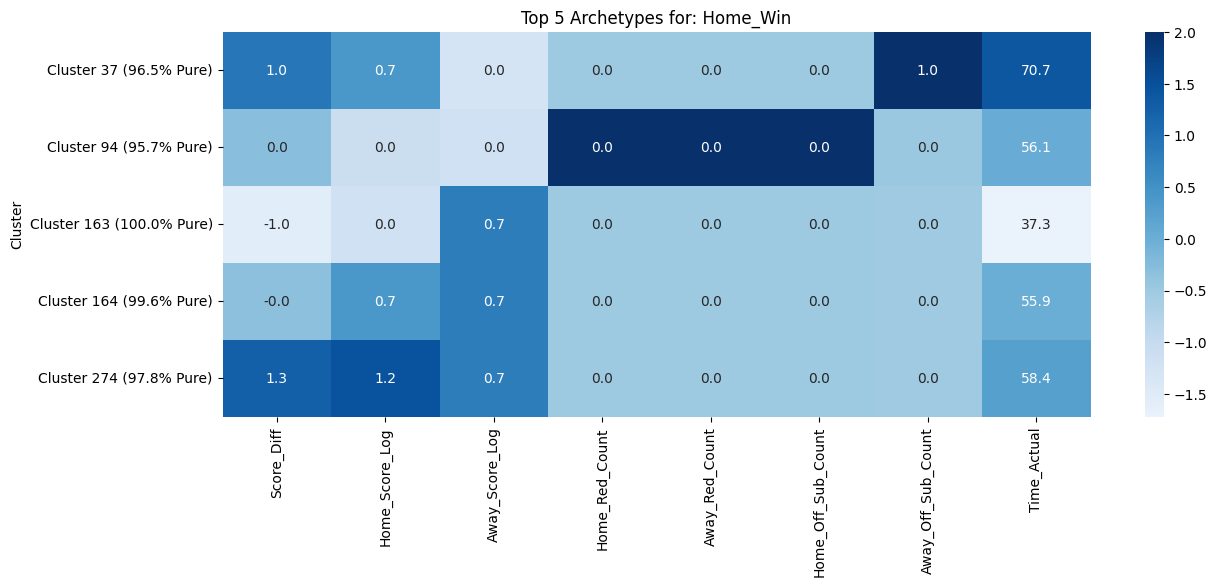

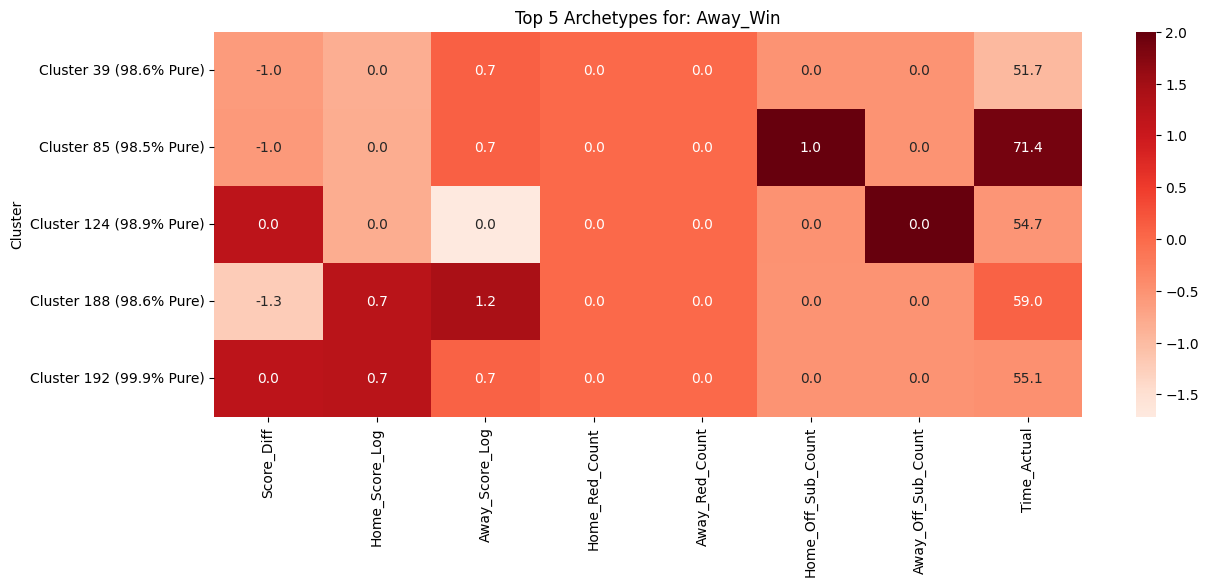

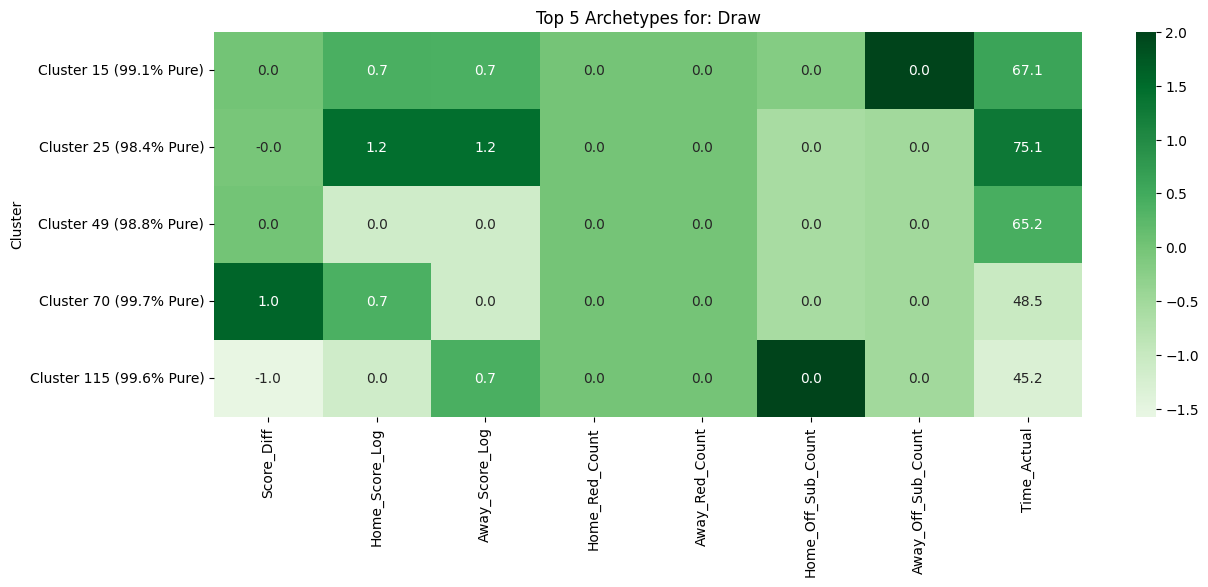


FINAL ANALYSIS:
By analyzing the 2D and 3D islands alongside the outcome-specific heatmaps, we
can see a tactical progression. The 5-minute resolution ensures that our Draw
signatures are not just 'mid-game 0-0' but can be identified as 'late-game
defensive holds' or 'early stalemate' scenarios.


In [5]:
# STAGE 3: OUTCOME-SPECIFIC ARCHETYPES
# =================================================================
print("\n--- Stage 3: Outcome-Specific Archetype Analysis ---")

analysis_df = X.copy()
analysis_df['Cluster'] = labels_opt
analysis_df['Outcome'] = y_true.values
analysis_df['Time_Actual'] = df_mod['Time'].values

purity = pd.crosstab(analysis_df['Cluster'], analysis_df['Outcome'], normalize='index')
dominant_outcome = purity.idxmax(axis=1)

def plot_outcome_heatmaps(target_outcome, color_map_name):
    relevant_clusters = purity.index[(dominant_outcome == target_outcome) & (purity.index != -1)]
    top_ids = analysis_df[analysis_df['Cluster'].isin(relevant_clusters)]['Cluster'].value_counts().iloc[:5].index
    
    if len(top_ids) > 0:
        stats = analysis_df[analysis_df['Cluster'].isin(top_ids)].groupby('Cluster').mean(numeric_only=True)
        stats = stats.drop(columns=['Time_Bin'])
        
        # --- IMPROVED Z-SCORE LOGIC ---
        # 1. Calculate Z-scores
        z_stats = stats.apply(zscore)
        # 2. Replace NaN values (caused by 0 variance) with 0.0 so they aren't blank
        z_stats = z_stats.fillna(0.0) 
        
        labels = [f"Cluster {idx} ({purity.loc[idx, target_outcome]*100:.1f}% Pure)" for idx in stats.index]
        
        plt.figure(figsize=(14, 5))
        # Use z_stats for color but stats for the text annotations
        sns.heatmap(z_stats, annot=stats, fmt=".1f", cmap=color_map_name, center=0, yticklabels=labels)
        plt.title(f"Top 5 Archetypes for: {target_outcome}")
        plt.show()

plot_outcome_heatmaps('Home_Win', 'Blues')
plot_outcome_heatmaps('Away_Win', 'Reds')
plot_outcome_heatmaps('Draw', 'Greens')

print("\nFINAL ANALYSIS:")
print("By analyzing the 2D and 3D islands alongside the outcome-specific heatmaps, we")
print("can see a tactical progression. The 5-minute resolution ensures that our Draw")
print("signatures are not just 'mid-game 0-0' but can be identified as 'late-game")
print("defensive holds' or 'early stalemate' scenarios.")